In [5]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")

using JJDFTX
using PyPlot

In [3]:
force_matrix, cell_map = phonon_force_matrix("totalE");

Number of phonon modes is: 87
If this is incorrect, something went wrong somewhere at some point.


In [17]:
phonon_dispersion(force_matrix, cell_map, [0, 0, 0], return_negative=true)

87-element Vector{Float64}:
 -1.6871249957877422e-8
 -8.761606788809009e-9
 -5.113257772267885e-9
  0.0017817595677708797
  0.0034477075628382837
  0.003449827839626698
  0.004136738978901754
  0.004137276688232403
  0.016903132268768405
  0.026721850689047703
  0.026721915824872326
  0.026819677181701262
  0.02681968416586171
  ⋮
  0.17082917008120377
  0.17082945500632257
  0.17098501180931722
  0.17098531456661195
  0.17099217954599127
  0.17105850550620405
  0.1713888964187645
  0.17138915967034105
  0.17158512721218555
  0.17158537177565364
  0.17181603889923963
  0.1718391393645666

In [25]:
phonon_dispersionmodes(force_matrix, cell_map, [0, 0, 0])[2][:, 3]

87-element Vector{ComplexF64}:
 0.045890146580572694 + 0.0im
  0.13152670753810178 + 0.0im
  0.13566803565608426 + 0.0im
  0.04589014658363622 + 0.0im
  0.13152670753994625 + 0.0im
  0.13566803566660318 + 0.0im
  0.04589014658075045 + 0.0im
   0.1315267075378719 + 0.0im
   0.1356680356569716 + 0.0im
  0.04589014658338576 + 0.0im
  0.13152670753973947 + 0.0im
   0.1356680356668242 + 0.0im
  0.04589014658070243 + 0.0im
                      ⋮
 0.040317357478502985 + 0.0im
  0.11555442029818186 + 0.0im
  0.11919283549070887 + 0.0im
  0.04031735747595199 + 0.0im
  0.11555442029672804 + 0.0im
    0.119192835481713 + 0.0im
  0.04031735747866271 + 0.0im
  0.11555442029818555 + 0.0im
  0.11919283549116684 + 0.0im
  0.05878823690950864 + 0.0im
  0.16849419361009782 + 0.0im
  0.17379950197937785 + 0.0im

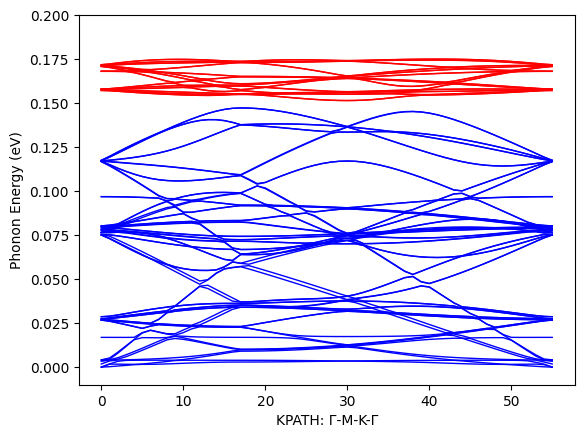

PyObject Text(0.5, 24.0, 'KPATH: Γ-M-K-Γ')

In [12]:
phonon_bands = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="./bandstruct.kpoints", return_negative=true);
plot(phonon_bands[:, 1:87-28], linewidth=1, color="blue")
plot(phonon_bands[:, 87-28+1:end], linewidth=1, color="red")
ylabel("Phonon Energy (eV)")
ylim(-0.01, 0.2)
xlabel("KPATH: Γ-M-K-Γ")

In [14]:
kpts = bandstructkpoints2q(filename = "../bandstruct.kpoints")

56-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0]
 [0.029411764706, 0.0, 0.0]
 [0.058823529412, 0.0, 0.0]
 [0.088235294118, 0.0, 0.0]
 [0.117647058824, 0.0, 0.0]
 [0.147058823529, 0.0, 0.0]
 [0.176470588235, 0.0, 0.0]
 [0.205882352941, 0.0, 0.0]
 [0.235294117647, 0.0, 0.0]
 [0.264705882353, 0.0, 0.0]
 [0.294117647059, 0.0, 0.0]
 [0.323529411765, 0.0, 0.0]
 [0.352941176471, 0.0, 0.0]
 ⋮
 [0.29333333304, -0.1466666652, 0.0]
 [0.2666666664, -0.133333332, 0.0]
 [0.23999999976, -0.1199999988, 0.0]
 [0.21333333312, -0.1066666656, 0.0]
 [0.18666666648, -0.0933333324, 0.0]
 [0.15999999984, -0.0799999992, 0.0]
 [0.1333333332, -0.066666666, 0.0]
 [0.10666666656, -0.0533333328, 0.0]
 [0.07999999992, -0.0399999996, 0.0]
 [0.05333333328, -0.0266666664, 0.0]
 [0.02666666664, -0.0133333332, 0.0]
 [0.0, 0.0, 0.0]

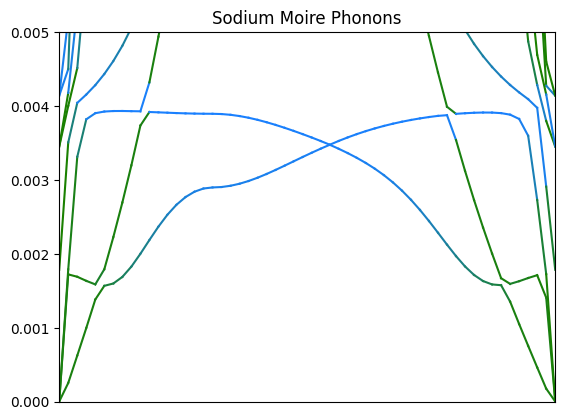

PyObject Text(0.5, 1.0, 'Sodium Moire Phonons')

In [21]:
for i in 1:87-28
    for j in 1:55
        y1= phonon_bands[j, i]
        y2 = phonon_bands[j+1, i]
        kpt = kpts[j]
        Na_Overlap = sum((abs.(phonon_dispersionmodes(force_matrix, cell_map, kpt)[2][85:87, i])).^2)
        plot([j, j+1], [y1, y2], color=[0.1, 0.5, Na_Overlap]) #linewidth=(3+Na_Overlap*4),)
    end
end
plot(phonon_bands[:, 87-28+1:end], linewidth=1, color="red")
xticks(Float64[])
ylim(0, 0.005)
xlim(1, 56)
title("Sodium Moire Phonons")